# Binary Classification with a Credit Card Fraud Dataset 

## Table of Contents
1. [Import Libraries](#import-libraries)
2. [Exploratory Data Analysis](#exploratory-data-analysis)

1 | <span style="color:green"> Import Libraries

In [1]:
import pandas as pd
import numpy as np
from numpy.linalg import inv

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from scipy.stats import zscore
from scipy.spatial.distance import cdist

In [2]:
# Import data
train = pd.read_csv("/workspaces/Machine-Learning/data/credit_fraud/train.csv", index_col="id")
test = pd.read_csv("/workspaces/Machine-Learning/data/credit_fraud/test.csv", index_col="id")

2 | <span style="color:green"> Exploratory Data Analysis

##### What we know about the data set

**Features:**
- There are 31 columns: 1 target variable, 30 continuous variables
- Time and Amount are raw.
- V1 to V28: PCA components (linear combinations of original features).
- Class: Target (1 = fraud, 0 = normal)

**General**
1. Total number of transactions - 219,129
2. Fraud : Legitimate = 218,660 : 469  
**Only 0.21% of the dataset is fraud transactions. Hence, the dataset is heavily imbalanced.**  
  


In [3]:
train.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,...,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000,219129.000000
mean,62377.415376,0.096008,0.048345,0.592102,0.069273,-0.161555,0.133688,-0.128224,0.149534,-0.048337,...,-0.031064,-0.050852,-0.050531,-0.002992,0.124005,0.009881,0.014034,0.017313,66.359803,0.002140
std,25620.348569,1.395425,1.159805,1.132884,1.253125,1.069530,1.202411,0.817207,0.716212,1.054143,...,0.422777,0.597812,0.318175,0.593100,0.406741,0.473867,0.233355,0.164859,150.795017,0.046214
min,0.000000,-29.807725,-44.247914,-19.722872,-5.263650,-37.591259,-25.659750,-31.179799,-28.903442,-8.756951,...,-14.689621,-8.748979,-11.958588,-2.836285,-3.958591,-1.858672,-9.234767,-4.551680,0.000000,0.000000
25%,47933.000000,-0.846135,-0.573728,-0.027154,-0.769256,-0.847346,-0.631835,-0.646730,-0.095948,-0.711444,...,-0.190418,-0.473099,-0.174478,-0.332540,-0.126080,-0.318330,-0.050983,-0.009512,5.990000,0.000000
50%,63189.000000,0.385913,0.046937,0.735895,0.064856,-0.229929,-0.087778,-0.098970,0.111219,-0.131323,...,-0.042858,-0.032856,-0.063307,0.038708,0.145934,-0.086388,0.015905,0.022163,21.900000,0.000000
75%,77519.000000,1.190661,0.814145,1.306110,0.919353,0.356856,0.482388,0.385567,0.390976,0.583715,...,0.109187,0.354910,0.060221,0.394566,0.402926,0.253869,0.076814,0.066987,68.930000,0.000000
max,120580.000000,2.430494,16.068473,6.145578,12.547997,34.581260,16.233967,39.824099,18.270586,13.423914,...,22.062945,6.163541,12.734391,4.572739,3.111624,3.402344,13.123618,23.263746,7475.000000,1.000000


In [4]:
train.Class.value_counts()

Class
0    218660
1       469
Name: count, dtype: int64

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 219129 entries, 0 to 219128
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    219129 non-null  float64
 1   V1      219129 non-null  float64
 2   V2      219129 non-null  float64
 3   V3      219129 non-null  float64
 4   V4      219129 non-null  float64
 5   V5      219129 non-null  float64
 6   V6      219129 non-null  float64
 7   V7      219129 non-null  float64
 8   V8      219129 non-null  float64
 9   V9      219129 non-null  float64
 10  V10     219129 non-null  float64
 11  V11     219129 non-null  float64
 12  V12     219129 non-null  float64
 13  V13     219129 non-null  float64
 14  V14     219129 non-null  float64
 15  V15     219129 non-null  float64
 16  V16     219129 non-null  float64
 17  V17     219129 non-null  float64
 18  V18     219129 non-null  float64
 19  V19     219129 non-null  float64
 20  V20     219129 non-null  float64
 21  V21     219129 

In [6]:
train.drop_duplicates(inplace=True) 

In [7]:
numeric_columns = (list(train.iloc[:2, :30])) # List always returns column names ONLY
print(numeric_columns)

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


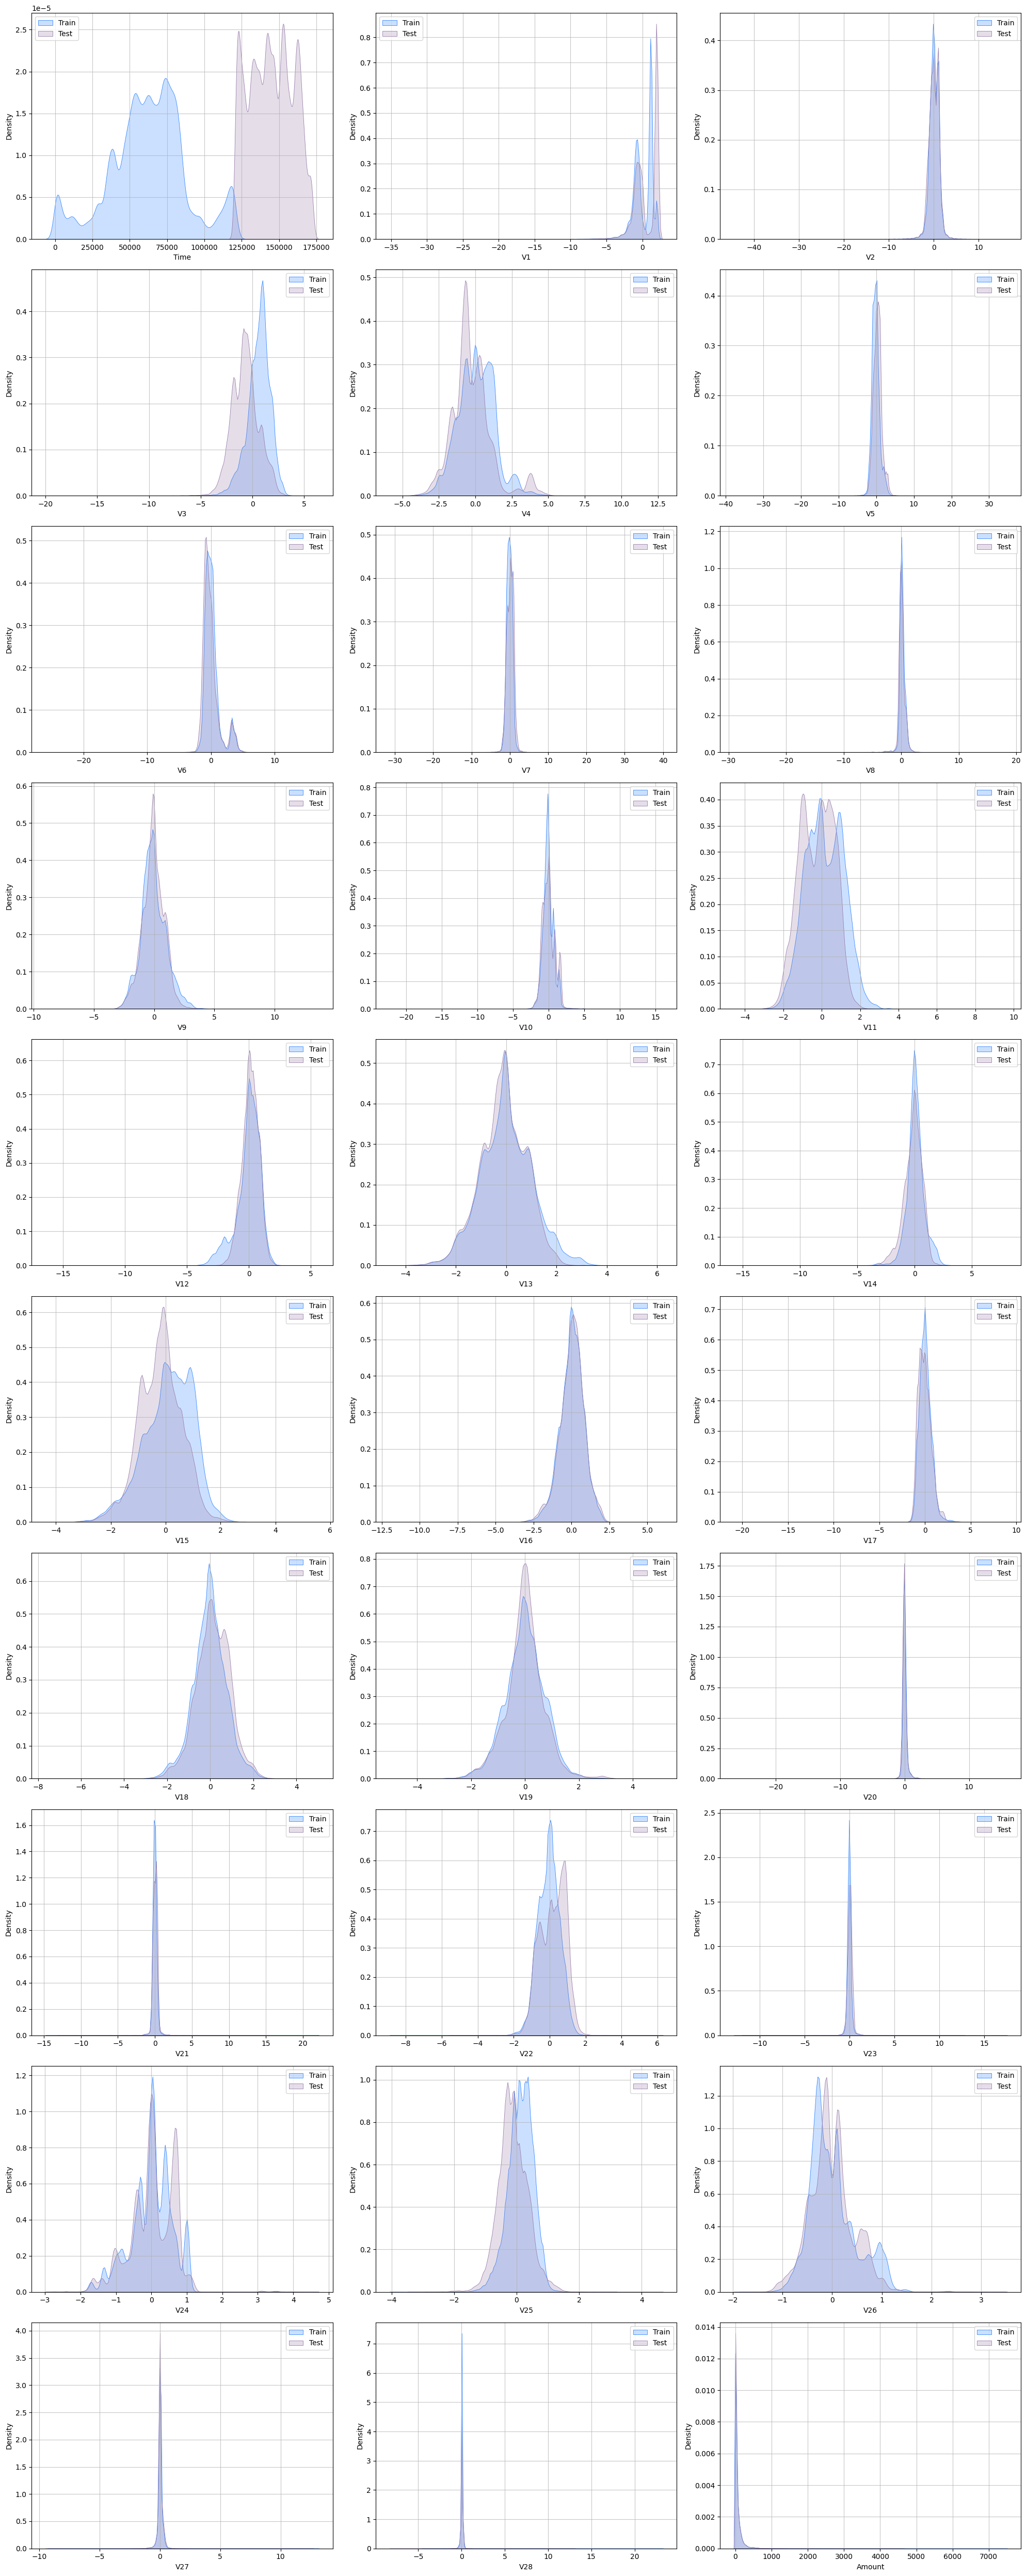

In [8]:
# Creating a Kernel Density Estimate (KDE) plot

fig = plt.figure(figsize=(20, 50)) #  Means 20 inches wide, 50 inches tall — very tall for many plots stacked vertically.
rows, cols = 10, 3 # 10×3 grid = 30 plots total.

for idx, col in enumerate(numeric_columns): # enumerate() generates idx automatically as a counter. numeric_columns only contains columns names
    # step 1: add a little area to the figure for each plot
        # This is adding a subplot (i.e., a little square or "cell" in the grid of the overall figure). 
        # Each subplot is where one KDE plot will be drawn.
        # idx + 1 because subplot numbering starts from 1, not 0.
    ax = fig.add_subplot(rows, cols, idx+1) # ax is the name of the subplot. It is a little square in the grid of the overall figure.

    # step 2: add grid lines 
    ax.grid(alpha=0.7, axis="both") # alpha is the transparency of the grid lines. 0 = invisible, 1 = fully visible.

    # step 3: add the KDE plot
    sns.kdeplot(data=train, x=col, fill=True, color="#3386FF", linewidth=0.6, label="Train")
    sns.kdeplot(data=test, x=col, fill=True, color="#987DAB", linewidth=0.6, label="Test")
    
    ax.set_xlabel(col) # Set the x-axis label to the name of the column
    ax.legend()

fig.tight_layout() # Adjust the layout of the figure to make it look nice
fig.show() # Show the figure with all the KDE plots


The distribution of Time is very different between the train and test sets.

In [9]:
train.drop('Time', axis=1, inplace=True)
test.drop('Time', axis=1, inplace=True)

In [10]:
numeric_columns = (list(train.iloc[:2, :30])) # List always returns column names ONLY
print(numeric_columns)

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


3 | <span style="color:green"> Data Imbalance Check

In [11]:
train_imbalance = list(train.Class.value_counts()) 
print(train_imbalance)

[218660, 469]


In [12]:
pie_values = [train_imbalance[0]/sum(train_imbalance), train_imbalance[1]/sum(train_imbalance)]

/tmp/ipykernel_100000/4189078520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train, x='Class', palette=["#3386FF", "#96D2FF"])
/tmp/ipykernel_100000/4189078520.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Fraud", "Fraud"])


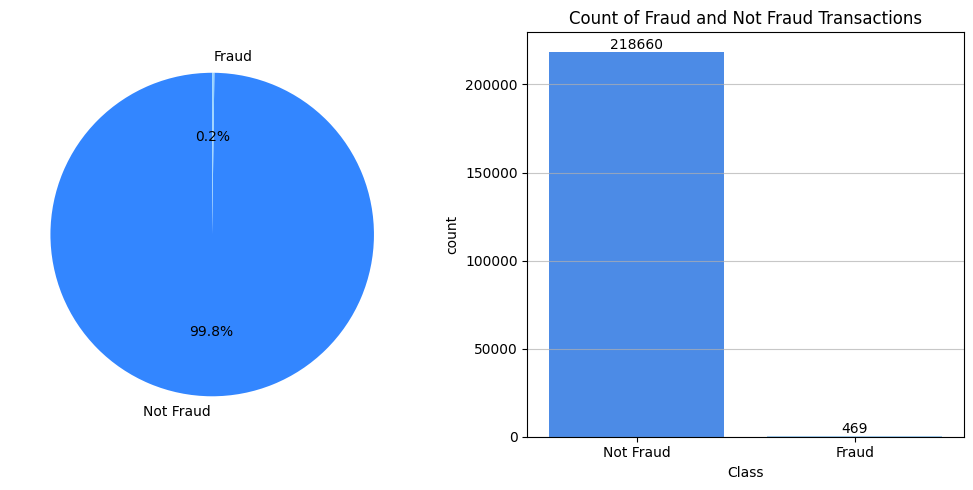

In [13]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 2, 1)
ax.grid(alpha=0.7, axis="both")
ax.pie(pie_values, labels=["Not Fraud", "Fraud"], autopct='%1.1f%%', startangle=90, colors=["#3386FF", "#96D2FF"])

ax = fig.add_subplot(1, 2, 2)
ax.grid(alpha=0.7, axis="both")
sns.countplot(data=train, x='Class', palette=["#3386FF", "#96D2FF"])
ax.set_xlabel("Class")
ax.set_xticklabels(["Not Fraud", "Fraud"])
ax.title.set_text("Count of Fraud and Not Fraud Transactions")

for container in ax.containers: # ax.containers is a list of all the containers in the plot. Each container is a group of bars.
    # This loop goes through each container (group of bars) in the plot and adds labels to them.
    ax.bar_label(container)

fig.tight_layout() # Adjusts the layout of the graphs so that they fit nicely in the figure and don't overlap

4 | <span style="color:green"> Outliers Check </span>

We use boxplots 

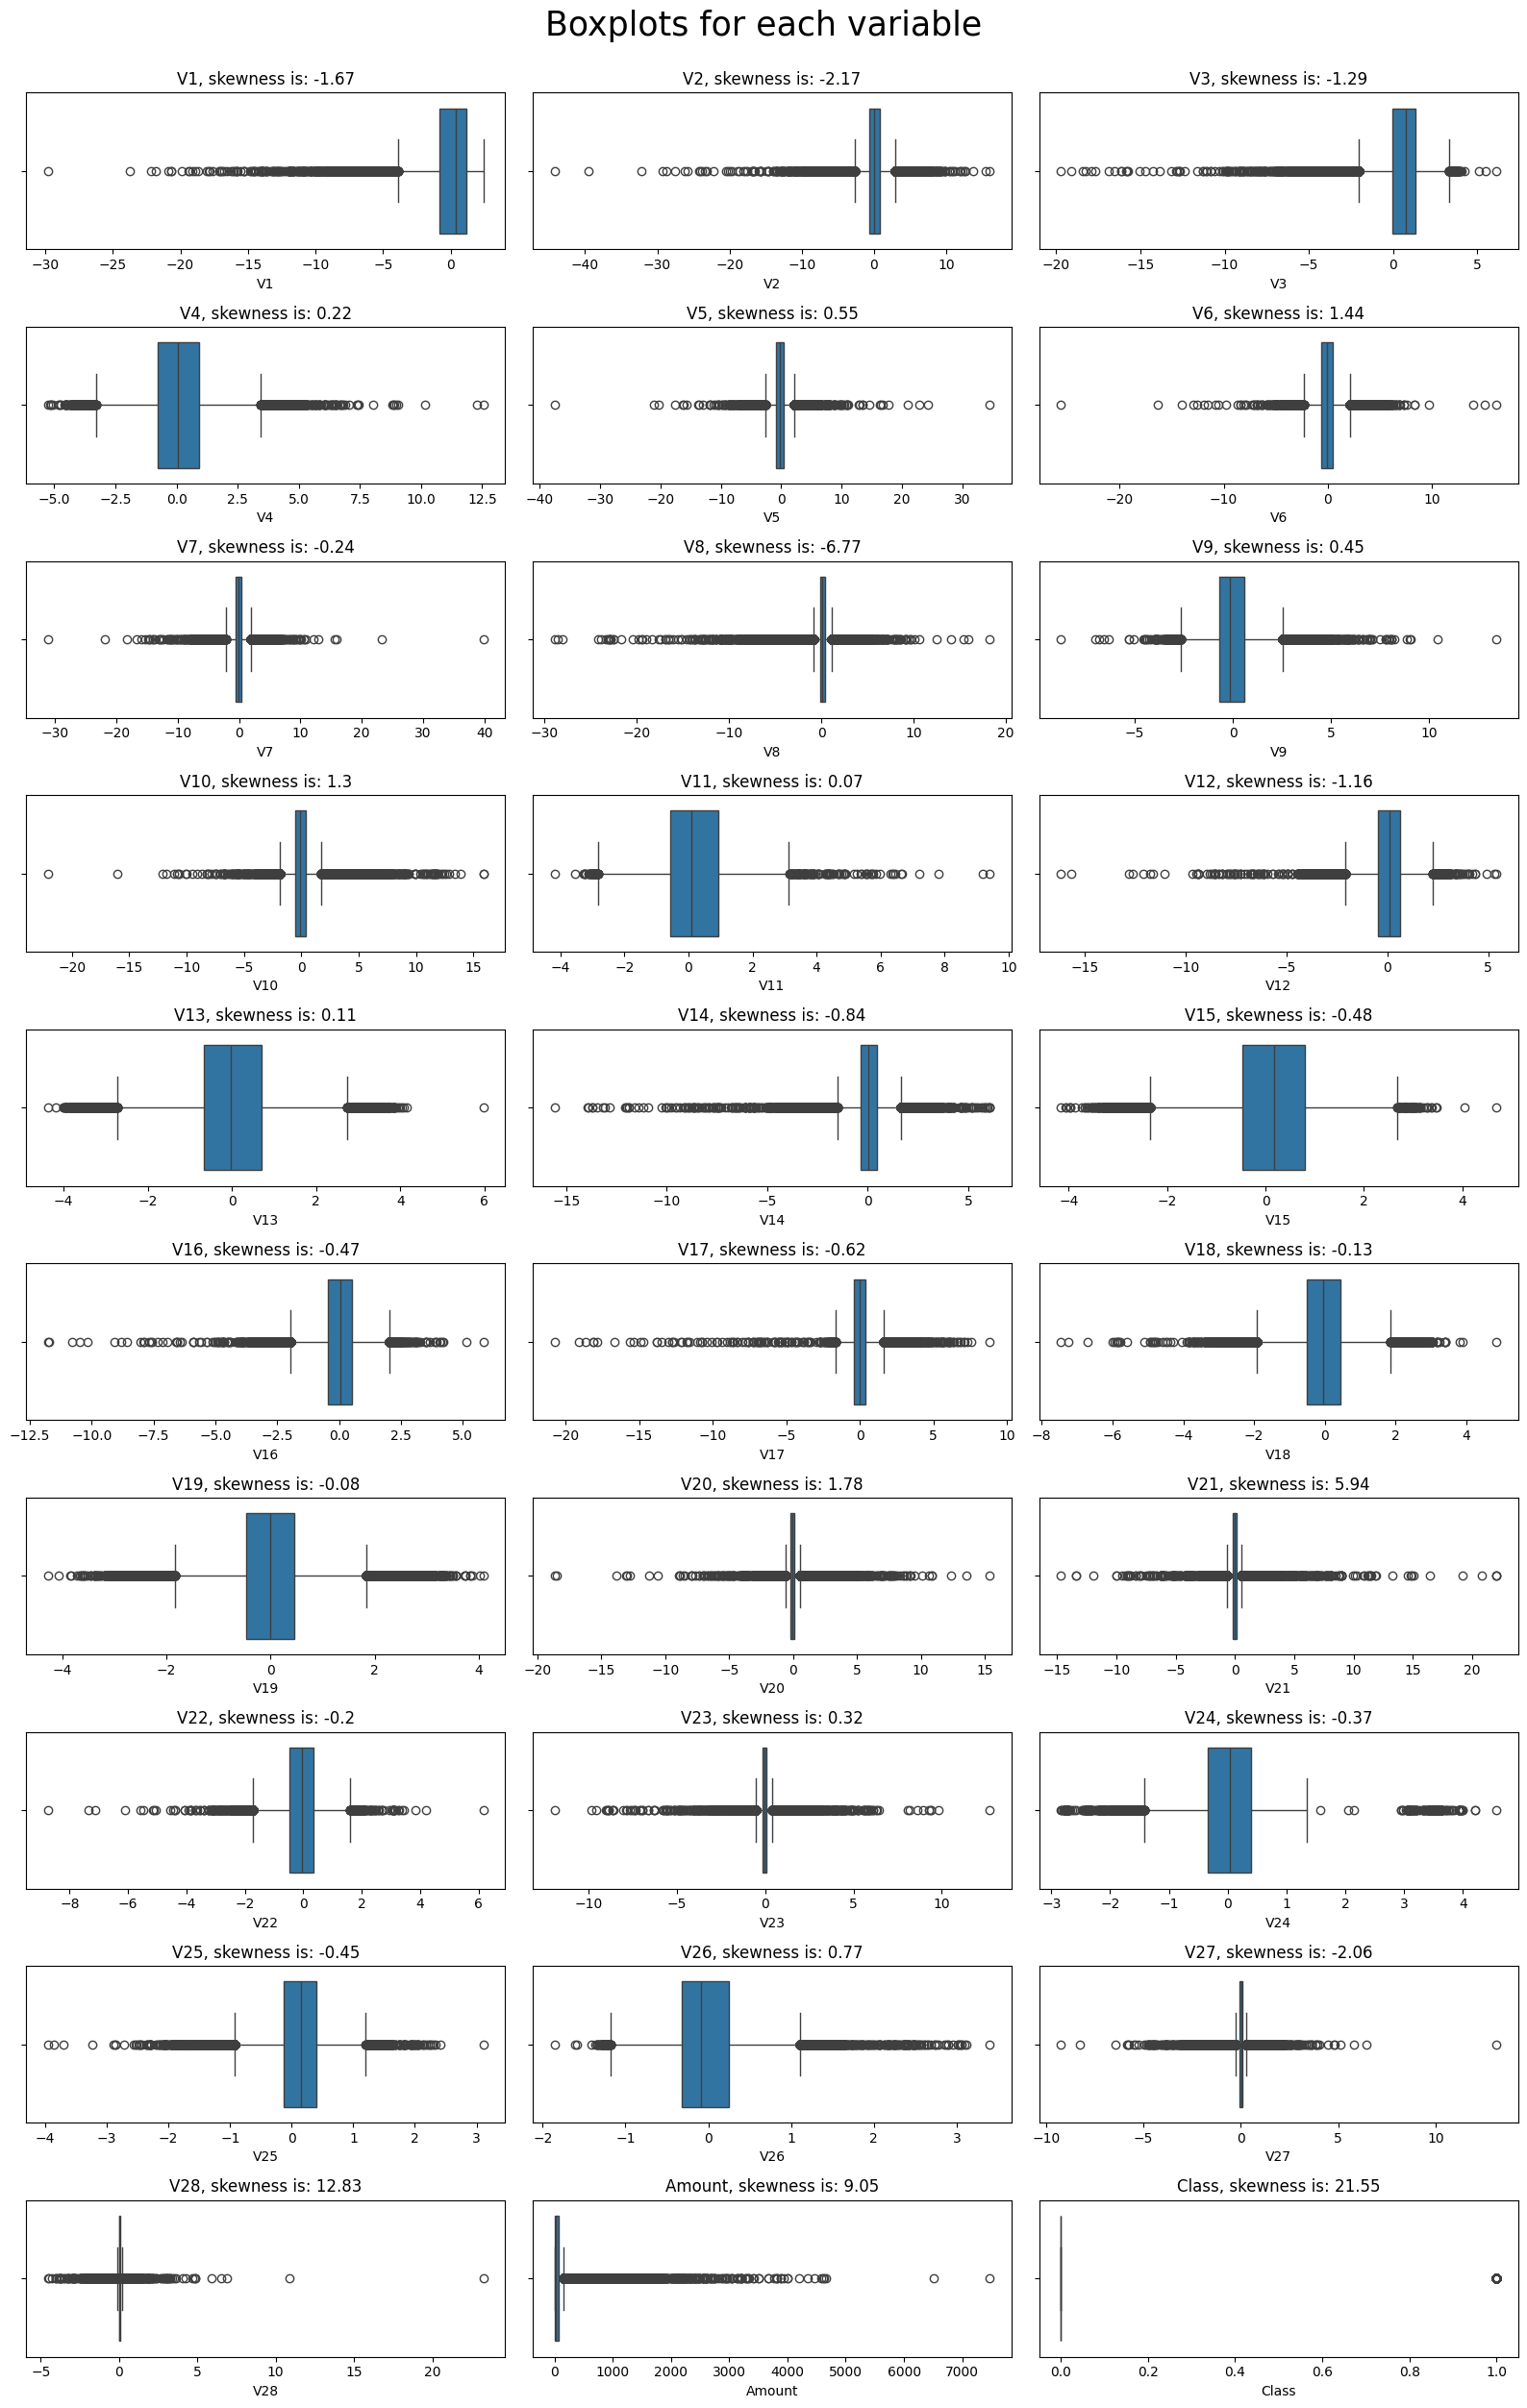

In [14]:
# checking boxplots
def boxplots_custom(dataset, columns_list, rows, cols, suptitle):
    # Setting the canvas and the grids
    fig, axs = plt.subplots(rows, cols, sharey=True, figsize=(16,25)) # We already defined 10 rows and 3 columns which is the canvas fig, then we assign the grids which is axs 
    fig.suptitle(suptitle,y=1, size=25) # This is the title of the whole figure. y=1 means it is at the top of the figure.
    axs = axs.flatten() # Change the grids of subplots to a 1D array. This makes it easier to loop through them.
    for i, data in enumerate(columns_list):
        sns.boxplot(data=dataset[data], orient='h', ax=axs[i])
        axs[i].set_title(data + ', skewness is: '+str(round(dataset[data].skew(axis = 0, skipna = True),2)))
        
boxplots_custom(dataset=train, columns_list=numeric_columns, rows=10, cols=3, suptitle='Boxplots for each variable')
plt.tight_layout()

We can see that while the mean is approximately centered around the 0, it is evident that the std deviation is not.
This implies that PCA-transformed variables are not standardised, and we should standardise the variables. 

In [15]:
train.describe().iloc[1:3, :] 
# train.describe().T[['mean', 'std']]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
mean,0.096008,0.048345,0.592102,0.069273,-0.161555,0.133688,-0.128224,0.149534,-0.048337,-0.039758,...,-0.031064,-0.050852,-0.050531,-0.002992,0.124005,0.009881,0.014034,0.017313,66.359803,0.002140
std,1.395425,1.159805,1.132884,1.253125,1.069530,1.202411,0.817207,0.716212,1.054143,0.821889,...,0.422777,0.597812,0.318175,0.593100,0.406741,0.473867,0.233355,0.164859,150.795017,0.046214


In [16]:
# Step 0: Separate features and target
pca_features = train.drop(columns=['Class'])   # All features including Amount
labels = train['Class']                    # Target variable

# Step 1: Standardize features (important before applying Z-score or Mahalanobis)
scaler = StandardScaler()
pca_features = pd.DataFrame(scaler.fit_transform(pca_features),
                            columns=pca_features.columns,
                            index=pca_features.index)  # Retain original indices

In [17]:
# Just extract mean and variance of the features from .describe()
pca_features.describe().iloc[1:3, :]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
mean,-8.300998e-18,1.556437e-17,-1.079130e-16,-4.150499e-18,3.112874e-17,-2.282774e-17,-7.263373e-17,5.188124e-18,-1.322972e-17,-1.245150e-17,...,-5.706936e-18,1.660200e-17,8.300998e-18,-1.452675e-17,-1.669927e-17,-1.245150e-17,-7.782186e-19,2.516240e-17,-1.763962e-17,-5.447530e-18
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00


4.1 | <span style="color:green"> Outlier Detection </span>

4.1.1 | <span style="color:orange"> Using Z-Score </span>

In [18]:
# ==========================================================
# Z-SCORE OUTLIER DETECTION
# ==========================================================

# Step 2: Compute Z-scores for all cells (absolute because we don't care about direction)
z_scores = np.abs(zscore(pca_features))  # Shape = (n_samples, n_features)

# Step 3: Define threshold (commonly 3 standard deviations from the mean)
zscore_threshold = 3

# Step 4: Create row-level mask: True if any feature in the row is an outlier
zscore_row_mask = np.any(z_scores > zscore_threshold, axis=1)

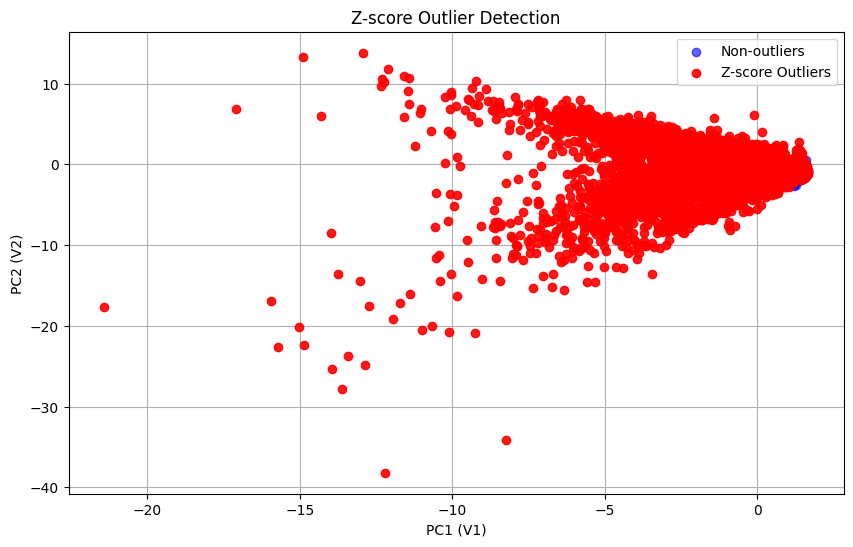

In [19]:
# Step 5: Visualize outliers (red on top)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(pca_features.iloc[~zscore_row_mask, 0], pca_features.iloc[~zscore_row_mask, 1],
           color='blue', label='Non-outliers', alpha=0.6, zorder=2)
ax.scatter(pca_features.iloc[zscore_row_mask, 0], pca_features.iloc[zscore_row_mask, 1],
           color='red', label='Z-score Outliers', alpha=0.9, zorder=3)
ax.set_xlabel('PC1 (V1)')
ax.set_ylabel('PC2 (V2)')
ax.set_title('Z-score Outlier Detection')
ax.legend()
plt.grid(True)
plt.show()

In [20]:
# Step 6: Filter the dataset
train_zscore_cleaned = train.loc[~zscore_row_mask]  # Only keep non-outlier rows

4.1.2 | <span style="color:orange"> Using Mahalanobis Distance </span>

In [21]:
# ==========================================================
# MAHALANOBIS DISTANCE OUTLIER DETECTION
# ==========================================================

# --- Assuming pca_features is your PCA-transformed NumPy array (n_samples x 28) ---

# Step 1: Ensure it's a clean 2D NumPy array
pca_features = np.asarray(pca_features)  # asarray does not change the shape of the data. Just converts lists / DataFrames to NumPy arrays without copying data.
assert pca_features.ndim == 2, "Input must be 2D"  # This checks if the input is 2D. If not, it raises an error.
n_components = pca_features.shape[1]  # This is the number of features or columns (28 in this case).

# Step 2: Compute mean and inverse covariance matrix
mean_vec = np.mean(pca_features, axis=0)  # Calculate the mean vector of the PCA features. This is the average of each column; axis=0 means go down the rows.
cov_matrix = np.cov(pca_features, rowvar=False)  # Calculate the covariance matrix. rowvar=False means that each column represents a variable and each row represents an observation.
inv_cov_matrix = inv(cov_matrix)  # Calculate the inverse of the covariance matrix. This is used in the Mahalanobis distance calculation.
# Note: The covariance matrix should be positive definite for the inverse to exist. If it's singular, this will throw an error.

# Step 3: Compute Mahalanobis distances for each point
# We use cdist from scipy, which is efficient and avoids shape issues.
# cdist will compute the Mahalanobis distance from each row in pca_features to the mean vector.
# The result is a 1D array of distances (one per row in the dataset).
from scipy.spatial.distance import cdist
mahal_distances = cdist(pca_features, [mean_vec], metric='mahalanobis', VI=inv_cov_matrix).flatten()

# Step 4: Set threshold (e.g., 97.5 percentile or chi-square cutoff with df = n_components)
# This determines how far a point's Mahalanobis distance must be from the center to be considered an outlier.
# Here, we're using a percentile cutoff instead of a strict chi-square threshold.
threshold = np.percentile(mahal_distances, 97.5)
outlier_indices = np.where(mahal_distances > threshold)[0]  # This returns the indices of the outlier rows.

# ⚠️ THIS IS WRONG and explained below for reference:
# mahal_mask = np.any(mahal_distances > threshold, axis=1)
# ❌ Mahalanobis distance is a 1D array. So using axis=1 on a 1D array will throw a ValueError — "axis 1 is out of bounds for array of dimension 1".
# ❌ Also, np.any(..., axis=1) implies you're checking across columns, but you only have one Mahalanobis distance per row.

# Initialize a boolean mask with all True (i.e., keep all rows by default)
mahal_mask = np.ones(len(train), dtype=bool)

# Set the indices of Mahalanobis outliers to False (i.e., mark for exclusion)
mahal_mask[outlier_indices] = False

# Filter the original dataset using the Mahalanobis mask
train_mahal_cleaned = train.loc[mahal_mask]


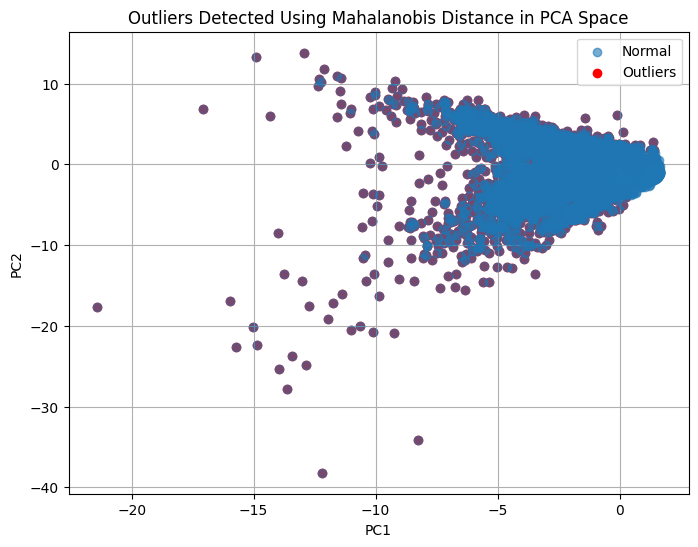

In [22]:
# Step 5: Optional visualization (first two PCs)
# We create a scatter plot to visualize outliers detected by Mahalanobis distance in PCA space (V1 vs V2).
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], label="Normal", alpha=0.6, zorder=2)
plt.scatter(pca_features[outlier_indices, 0], pca_features[outlier_indices, 1],
            color='red', label="Outliers", zorder=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Outliers Detected Using Mahalanobis Distance in PCA Space")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# -------------------------
# Step 3: Compare Z-score and Mahalanobis Outliers
# -------------------------

# Convert boolean mask and index array to sets of row indices
z_outliers = set(np.where(zscore_row_mask)[0])           # Indices flagged by Z-score
mahal_outliers = set(outlier_indices)             # Indices flagged by Mahalanobis

# Compute set intersections and differences
both = z_outliers & mahal_outliers                # Rows flagged by both methods
only_z = z_outliers - mahal_outliers              # Z-score only
only_mahal = mahal_outliers - z_outliers          # Mahalanobis only

# Display comparison results
print(f"Outliers detected by both methods: {len(both)}")
print(f"Outliers detected only by Z-score: {len(only_z)}")
print(f"Outliers detected only by Mahalanobis: {len(only_mahal)}")

Outliers detected by both methods: 5457
Outliers detected only by Z-score: 23813
Outliers detected only by Mahalanobis: 22


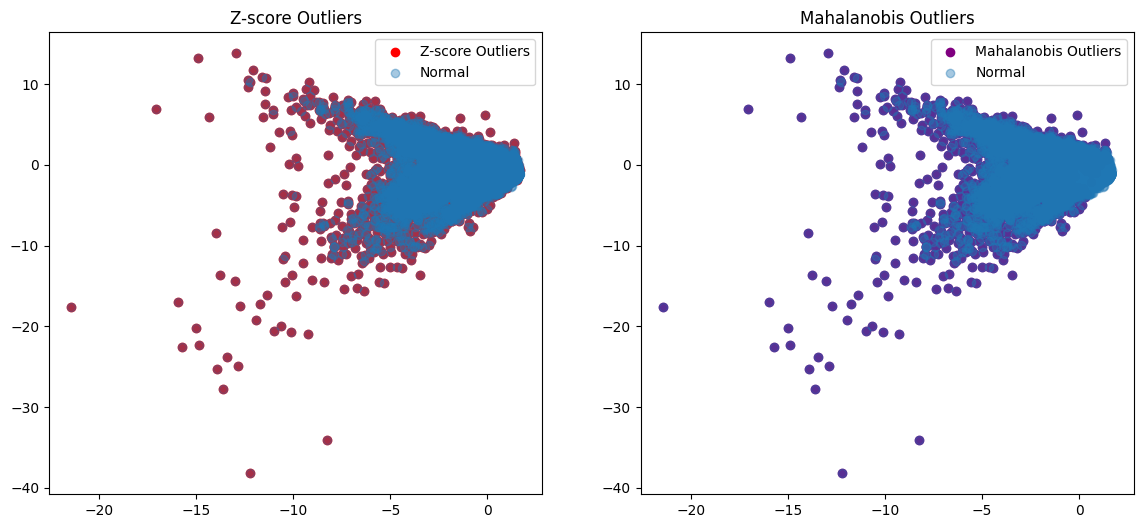

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Z-score plot
ax[0].scatter(pca_features[zscore_row_mask, 0], pca_features[zscore_row_mask, 1], color='red', label='Z-score Outliers')
ax[0].scatter(pca_features[:, 0], pca_features[:, 1], alpha=0.4, label='Normal')
ax[0].set_title("Z-score Outliers")
ax[0].legend()

# Mahalanobis plot
ax[1].scatter(pca_features[outlier_indices, 0], pca_features[outlier_indices, 1], color='purple', label='Mahalanobis Outliers')
ax[1].scatter(pca_features[:, 0], pca_features[:, 1], alpha=0.4, label='Normal')
ax[1].set_title("Mahalanobis Outliers")
ax[1].legend()

plt.show()

In [27]:
print(f"Original dataset size: {len(train)}")
print(f"Z-score cleaned size: {len(train_zscore_cleaned)}")
print(f"Mahalanobis cleaned size: {len(train_mahal_cleaned)}")

Original dataset size: 219129
Z-score cleaned size: 189859
Mahalanobis cleaned size: 213650


In [30]:
# Combined outlier mask
combined_outlier_mask = zscore_row_mask | ~mahal_mask
combined_clean_mask = ~combined_outlier_mask

# Filter the original dataset using the combined mask
train_combined_cleaned = train.loc[combined_clean_mask]  # Only keep non-outlier rows
# Check the size of the cleaned dataset
print(f"Combined cleaned size: {len(train_combined_cleaned)}")


Combined cleaned size: 189837


In [31]:
print ('The amount of frauds in df before dropping outliers: ', len(train[train['Class'] == 1]))
print ('The amount of frauds in df after dropping outliers: ', len(train_combined_cleaned[train_combined_cleaned['Class'] == 1]))

The amount of frauds in df before dropping outliers:  469
The amount of frauds in df after dropping outliers:  228


5 | <span style="color:green"> Dealing with Duplicated Values </span>

In [ ]:
print('Number of duplicated values in dataset: ', train.duplicated().sum())
print('Number of duplicated values in dataset: ', train_combined_cleaned.duplicated().sum())

Number of duplicated values in dataset:  94
Number of duplicated values in dataset:  88
